# EELS Acquisition

Acquire a full-frame image, a cropped rectangle scan, and images from multiple detectors.


### Run the servers

Make sure you are on the VPN and the AutoScript server is running. Then start the asyncroscopy Tango servers from the repository root:

```bash
uv run startup_scripts/run_servers.py
```


### Imports


In [1]:
import os
import json
import tango
import numpy as np
from pprint import pprint
import matplotlib.pyplot as plt
from tiled.client import from_uri

%matplotlib ipympl

### Ping servers


In [2]:
DB_HOST = "10.46.217.241"
# DB_HOST = "localhost"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

scan = tango.DeviceProxy("asyncroscopy/scan/default")
camera = tango.DeviceProxy("asyncroscopy/camera/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")
eels = tango.DeviceProxy("asyncroscopy/eels/default")

for proxy in [scan, microscope, data, eels]:
    print(proxy)
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())


SCAN(asyncroscopy/scan/default)
asyncroscopy/scan/default ON
AutoScriptMicroscope(asyncroscopy/instrument/default)
asyncroscopy/instrument/default ON
DATA(asyncroscopy/data/default)
asyncroscopy/data/default ON
EELS(asyncroscopy/eels/default)
asyncroscopy/eels/default ON


### Set Tiled Client


In [10]:
config = json.loads(data.get_config())
client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

Tiled keys: ['camera_image_BM-Ceta_20260717T152423178393.h5', 'camera_image_BM-Ceta_20260724T102044350411.h5', 'stem_image_HAADF_20260710T131230285541.h5', 'stem_image_HAADF_20260722T110415719342.h5', 'stem_image_HAADF_20260722T110422928758.h5', 'stem_image_HAADF_20260722T110427123927.h5', 'stem_image_HAADF_20260722T110441341254.h5', 'stem_image_HAADF_20260722T110445556472.h5', 'stem_image_HAADF_20260722T110450190803.h5', 'stem_image_HAADF_20260722T110454703812.h5', 'stem_image_HAADF_20260722T110459079456.h5', 'stem_image_HAADF_20260722T110833269600.h5', 'stem_image_HAADF_20260722T110837508121.h5', 'stem_image_HAADF_20260722T110841960693.h5', 'stem_image_HAADF_20260722T110846546622.h5', 'stem_image_HAADF_20260722T110850834111.h5', 'stem_image_HAADF_20260727T163836044499.h5', 'stem_image_HAADF_20260727T163855717680.h5', 'stem_image_HAADF_20260727T163930916461.h5', 'stem_image_HAADF_20260727T163932290115.h5', 'stem_image_HAADF_20260727T163933595589.h5', 'stem_image_HAADF_20260727T1639353

In [11]:
client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

Tiled keys: ['camera_image_BM-Ceta_20260717T152423178393.h5', 'camera_image_BM-Ceta_20260724T102044350411.h5', 'stem_image_HAADF_20260710T131230285541.h5', 'stem_image_HAADF_20260722T110415719342.h5', 'stem_image_HAADF_20260722T110422928758.h5', 'stem_image_HAADF_20260722T110427123927.h5', 'stem_image_HAADF_20260722T110441341254.h5', 'stem_image_HAADF_20260722T110445556472.h5', 'stem_image_HAADF_20260722T110450190803.h5', 'stem_image_HAADF_20260722T110454703812.h5', 'stem_image_HAADF_20260722T110459079456.h5', 'stem_image_HAADF_20260722T110833269600.h5', 'stem_image_HAADF_20260722T110837508121.h5', 'stem_image_HAADF_20260722T110841960693.h5', 'stem_image_HAADF_20260722T110846546622.h5', 'stem_image_HAADF_20260722T110850834111.h5', 'stem_image_HAADF_20260727T163836044499.h5', 'stem_image_HAADF_20260727T163855717680.h5', 'stem_image_HAADF_20260727T163930916461.h5', 'stem_image_HAADF_20260727T163932290115.h5', 'stem_image_HAADF_20260727T163933595589.h5', 'stem_image_HAADF_20260727T1639353

### Configure scan


In [19]:
eels.exposure_time = 0.005

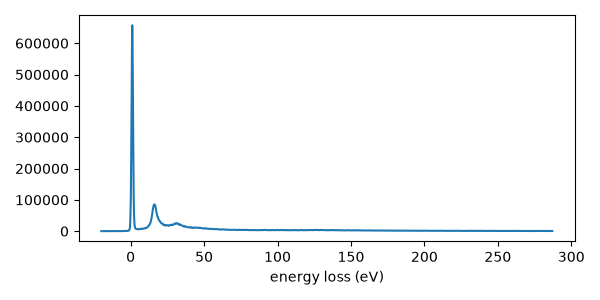

In [22]:
data_key = eels.acquire_eels_spectrum()

spectrum = client[data_key]['spectrum'].read()

metadata = dict(client[data_key]["spectrum"].metadata)
energy_scale = np.arange(len(spectrum))*metadata['dispersion']+metadata['offset']
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(energy_scale, spectrum)
plt.xlabel(f"energy loss ({metadata['energy_units']})")
plt.tight_layout()

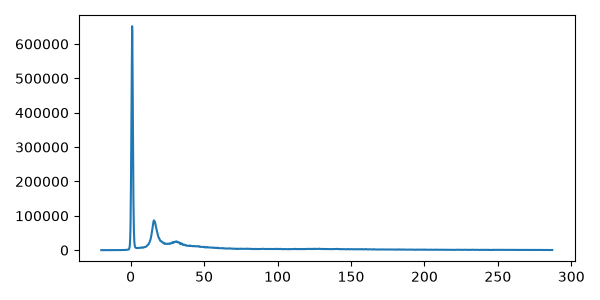

In [21]:
energy_scale = np.arange(len(spectrum))*metadata['dispersion']+metadata['offset']
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(energy_scale, spectrum)
plt.tight_layout()

In [16]:
metadata

{'acquisition_type': 'spectrum',
 'detector': 'eels',
 'dispersion': 0.15000000596046448,
 'dispersion_units': 'eV/channel',
 'energy_units': 'eV',
 'exposure_time': 0.0001,
 'number_of_frames': 1,
 'offset': -20.000001907348633,
 'start_energy': -20.000001907348633}